In [18]:
IMAGESIZE = 200
RANDOM_STATE = 42

In [19]:
from typing import Callable
import os
from dataclasses import dataclass
import numpy as np
from PIL import Image as PILImage


@dataclass
class ProvidedImage:
    filename: str
    data: np.ndarray[np.ndarray[np.uint8]]
    label: int

    def __init__(self, filename, label, image=None):
        self.filename = filename
        self.label = label
        self.data = image

    def load_image(self, file_path: str, width: int = 300, height: int = 300) -> "ProvidedImage" or None:
        try:
            loadedImage = PILImage.open(file_path)
            if loadedImage.mode == 'P' and 'transparency' in loadedImage.info:
                loadedImage = loadedImage.convert('RGBA')
            loadedImage = loadedImage.convert('RGB')
            loadedImage = loadedImage.resize((width, height))
            processedImage = np.array(loadedImage, dtype=np.float32)

            # Gifs have 4 dimensions because they have multiple frames
            if processedImage.ndim == 4: processedImage = processedImage[0]

            self.data = processedImage
            return self
        except Exception as e:
            print(f'Skipped {file_path}: {e}')
            return None

    def apply_transform(self, transformFunction: Callable[
        [np.ndarray[np.ndarray[np.uint8]]], np.ndarray[np.ndarray[np.uint8]]]):
        return ProvidedImage(self.filename, self.label, transformFunction(self.data))


def readImages(path: str, label: int, width=IMAGESIZE, height=IMAGESIZE):
    images: [ProvidedImage] = []
    for imagePath in os.listdir(path):
        image = ProvidedImage(imagePath, label).load_image(os.path.join(path, imagePath), width, height)
        if image is not None:
            images.append(image)
    return images

In [20]:
from scipy.ndimage import gaussian_filter


def transform_to_fft(data: np.ndarray[np.ndarray[np.uint8]]) -> np.ndarray[np.ndarray[np.uint8]]:
    fft_channels = []
    for c in range(3):
        fft = np.fft.fftshift(np.fft.fft2(data[:, :, c]))
        magnitude = np.log(np.abs(fft) + 1)
        fft_channels.append(magnitude)
    result = np.stack(fft_channels, axis=-1)
    return (result - result.min()) / (result.max() - result.min() + 1e-8) * 255.0


def transform_to_noise(data: np.ndarray[np.ndarray[np.uint8]]) -> np.ndarray[np.ndarray[np.uint8]]:
    smooth = gaussian_filter(data, sigma=2)
    result = data - smooth
    return (result - result.min()) / (result.max() - result.min() + 1e-8) * 255.0

In [21]:
realImages: [ProvidedImage] = readImages("../semester_assignment/Art_shuffled/RealArt/", 0, IMAGESIZE, IMAGESIZE)
aiImages: [ProvidedImage] = readImages("../semester_assignment/Art_shuffled/AiArtData/", 1, IMAGESIZE, IMAGESIZE)

In [22]:
allImages: [ProvidedImage] = [*realImages, *aiImages]

all_fft = [image.apply_transform(transform_to_fft) for image in allImages]
all_noise = [image.apply_transform(transform_to_noise) for image in allImages]

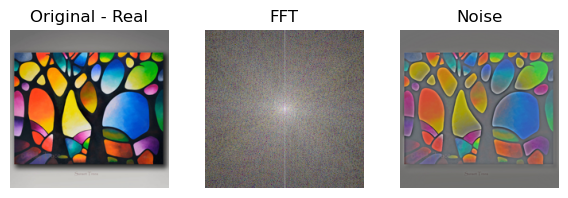

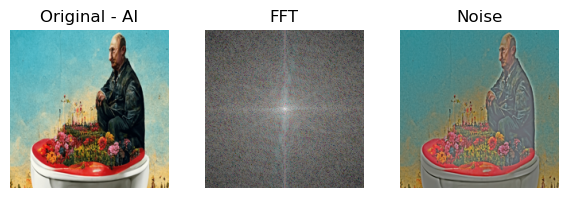

In [23]:
import matplotlib.pyplot as plt


def show_transformations(original, label):
    fig, axes = plt.subplots(1, 3, figsize=(6, 2))

    axes[0].imshow(original / 255.0)
    axes[0].set_title(f"Original - {'AI' if label == 1 else 'Real'}")
    axes[0].axis('off')

    fft = transform_to_fft(original)
    axes[1].imshow(fft / 255.0)
    axes[1].set_title("FFT")
    axes[1].axis('off')

    noise = transform_to_noise(original)
    axes[2].imshow(noise / 255.0)
    axes[2].set_title("Noise")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


show_transformations(realImages[0].data, realImages[0].label)  # X_real = np.stack([img.data for img in realImages])
show_transformations(aiImages[0].data, aiImages[0].label)

In [24]:
from sklearn.model_selection import train_test_split

X_fft   = np.stack([img.data for img in all_fft]).astype(np.float32)
X_noise = np.stack([img.data for img in all_noise]).astype(np.float32)
y       = np.array([img.label for img in allImages]).astype(np.float32)

X_fft_train, X_fft_tmp, X_noise_train, X_noise_tmp, y_train, y_tmp = train_test_split(
    X_fft, X_noise, y, test_size=0.2, random_state=RANDOM_STATE
)

X_fft_val, X_fft_test, X_noise_val, X_noise_test, y_val, y_test = train_test_split(
    X_fft_tmp, X_noise_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE
)

In [25]:
import keras as keras
from keras import layers, Model


def build_model():
    inputs = keras.Input(shape=(IMAGESIZE, IMAGESIZE, 3))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                  )
    return model

In [26]:

from keras.src.legacy.preprocessing.image import ImageDataGenerator

fft_datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True
)
fft_train_gen = fft_datagen.flow(X_fft_train, y_train, batch_size=32)

noise_datagen = ImageDataGenerator(horizontal_flip=True)
noise_train_gen = noise_datagen.flow(X_noise_train, y_train, batch_size=32)

In [27]:
from keras.src.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

# Model 1: FFT
print("Training FFT-Model...")
model_fft = build_model()
model_fft.fit(fft_train_gen, epochs=20, validation_data=(X_fft_val, y_val), callbacks=callbacks)

# Model 2: Noise
print("Training Noise-Model...")
model_noise = build_model()
model_noise.fit(noise_train_gen, epochs=20, validation_data=(X_noise_val, y_val), callbacks=callbacks)

Training FFT-Model...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5551 - loss: 0.6999 - val_accuracy: 0.5567 - val_loss: 9.8533 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.5987 - loss: 0.6643 - val_accuracy: 0.5567 - val_loss: 5.2322 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6051 - loss: 0.6708 - val_accuracy: 0.5567 - val_loss: 7.5417 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6103 - loss: 0.6598 - val_accuracy: 0.5567 - val_loss: 4.8797 - learning_rate: 0.0010
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6385 - loss: 0.6474 - val_accuracy: 0.5567 - val_loss: 6.8595 - learning_rate: 0.0010
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6077 - loss: 0.6449 - val_accuracy: 0.5567 - val_loss: 5.1183 - learning_rate: 0.0010
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6372 - loss: 0

In [28]:
from sklearn.metrics import classification_report

pred_fft = model_fft.predict(X_fft_test)
pred_noise = model_noise.predict(X_noise_test)
pred_ensemble = (pred_fft + pred_noise) / 2

print("FFT Model")
print(classification_report(y_test, (pred_fft > 0.5).astype(int), target_names=['Real', 'AI']))

print("Noise Model")
print(classification_report(y_test, (pred_noise > 0.5).astype(int), target_names=['Real', 'AI']))

print("Combination of both models")
print(classification_report(y_test, (pred_ensemble > 0.5).astype(int), target_names=['Real', 'AI']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step
FFT Model
              precision    recall  f1-score   support

        Real       0.59      0.60      0.60        43
          AI       0.69      0.67      0.68        55

    accuracy                           0.64        98
   macro avg       0.64      0.64      0.64        98
weighted avg       0.64      0.64      0.64        98

Noise Model
              precision    recall  f1-score   support

        Real       0.44      1.00      0.61        43
          AI       0.00      0.00      0.00        55

    accuracy                           0.44        98
   macro avg       0.22      0.50      0.30        98
weighted avg       0.19      0.44      0.27        98

Combination of both models
              precision    recall  f1-score   support

        Real       0.44      1.00      0.61        43
          AI       0.00      0.00      0.00        55

    accuracy                           0.44        98
 

/Users/pascalkessler/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pascalkessler/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pascalkessler/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Conclusion, or maybe like after question:

The results are not that bad, in combination we can predict an Image by ~68% and in recall for AI images in like 85%.
But:
we have our other model you can see in task_t_pattern.ipynb, and there we have (we think its overfitted) like ~92%+ accuracy.
But there we only learn patterns in the image, so like the motive, faces...
That is in our opinion not really a good measure to predict AI/Real, because if ai learns better about maybe human anatomics, there is no difference in that patterns anymore.
But then why is this model worse than the pattern based model?
  